# Mental Health Data Science Analysis
## Full Pipeline: EDA → Feature Engineering → Modelling → Threshold Optimisation

**Dataset:** 2,000 records | 18 features | 3 binary targets (Depression, Anxiety, Burnout)  
**Pipeline Steps:** Data Loading → Quality Check → EDA → Correlation Analysis → Group Analysis → Feature Engineering → Model Training → Confusion Matrix → Feature Importance → Threshold Optimisation → PR/ROC Curves

---
> Each code cell is followed by a ** Interpretation cell** explaining what the output means, why the numbers matter, and what a data scientist should conclude from them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')
 
# Set a clean plot style used throughout all steps
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

## Library Imports
**No output — but this is the foundation of everything.**

| Library | Role |
|---|---|
| `pandas` / `numpy` | Data loading, manipulation, math |
| `matplotlib` / `seaborn` | All charts and visualisations |
| `LogisticRegression` | Simple linear model — our baseline |
| `RandomForestClassifier` | Ensemble of decision trees — handles non-linearity |
| `GradientBoostingClassifier` | Sequential tree builder — often the strongest model |
| `classification_report`, `roc_auc_score`, `confusion_matrix` | Performance measurement tools |

`warnings.filterwarnings('ignore')` suppresses non-critical alerts to keep output readable.  
`sns.set_theme` and `plt.rcParams` ensure visual consistency across all charts.

In [4]:
# Load dataset
df = pd.read_csv("mental_health.csv")

# Preview data
df.head()


,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


## First Look at the Data

**Reading the first 5 rows tells us the story immediately:**

- **Person 1** (age 54, stress=8, sleep=6.5hrs, screen=10.2hrs) → Depression=1, Anxiety=1, Burnout=1 — the worst possible outcome
- **Person 4** (age 58, stress=2, sleep=9hrs) → Depression=0, Anxiety=0, Burnout=0 — the healthiest profile

Even from 5 rows, the pattern is visible: **high stress + low sleep + high screen time = bad outcomes**.

**Column types spotted:**
- `Gender`, `Occupation`, `Physical_Activity` are text (`object`) → must be encoded before modelling
- `Night_Usage`, `Smoking`, `Alcohol` are binary 0/1 flags
- `Depression`, `Anxiety`, `Burnout` are our **3 prediction targets** (binary: 0=No, 1=Yes)

In [5]:

print("=== SHAPE ===")
print(f"Rows: {df.shape[0]},  Columns: {df.shape[1]}")
 
print("\n=== COLUMN NAMES & DATA TYPES ===")
print(df.dtypes)
 
print("\n=== FIRST 5 ROWS ===")
print(df.head())
 
print("\n=== BASIC STATISTICS ===")
print(df.describe().round(2))

=== SHAPE ===
Rows: 2000,  Columns: 18

=== COLUMN NAMES & DATA TYPES ===
Person_ID                     int64
Age                           int64
Gender                       object
Occupation                   object
Daily_Screen_Time           float64
Social_Media_Usage          float64
Night_Usage                   int64
Sleep_Hours                 float64
Stress_Level                  int64
Work_Study_Hours            float64
Physical_Activity            object
Social_Interaction_Score      int64
Caffeine_Intake               int64
Smoking                       int64
Alcohol                       int64
Depression                    int64
Anxiety                       int64
Burnout                       int64
dtype: object

=== FIRST 5 ROWS ===
   Person_ID  Age  Gender Occupation  Daily_Screen_Time  Social_Media_Usage  \
0          1   54    Male    Student               10.2                 7.5   
1          2   44    Male    Student                6.8                 4.5   
2    

## Shape, Data Types & Basic Statistics

**Shape: 2,000 rows × 18 columns** — large enough for machine learning.

**Key statistics interpreted:**

| Feature | Mean | What it means |
|---|---|---|
| `Age` | 37.69 | Working-age adults + some teens. Range 16–59 |
| `Daily_Screen_Time` | 6.94 hrs | Average person spends nearly 7 hrs/day on screens |
| `Sleep_Hours` | 6.01 hrs | Already below the recommended 8 hrs |
| `Stress_Level` | 5.41/10 | Moderate average; 75th percentile is 8/10 |
| `Depression` mean | 0.50 | **50% of the dataset is depressed** — this is suspicious |
| `Anxiety` mean | 0.51 | Same near-perfect 50/50 split |
| `Burnout` mean | 0.52 | Same pattern across all 3 targets |

>  **Critical observation:** Real-world depression prevalence is ~15–20%, not 50%. The near-perfect balance across all 3 targets strongly suggests this is **synthetically generated data**. This is fine for learning the workflow but limits real-world clinical applicability.

In [8]:
# — MISSING VALUES & DATA QUALITY CHECK
# WHY: Missing or duplicate data will silently corrupt every
#      result downstream. We must identify and deal with them
#      before touching any analysis or model.

print("=== MISSING VALUES PER COLUMN ===")
print(df.isnull().sum())
# isnull() marks True where a value is NaN
# .sum() counts the Trues per column
 
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")
 
print("\n=== DUPLICATE ROWS ===")
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
# duplicated() returns True for rows that are exact copies
# We always drop dupes to avoid inflating counts/model accuracy
 
print("\n=== UNIQUE VALUES PER CATEGORICAL COLUMN ===")
for col in ['Gender', 'Occupation', 'Physical_Activity']:
    print(f"{col}: {df[col].unique()}")
# Checking for typos, unexpected categories, or inconsistent casing
 
print("\n=== VALUE RANGE CHECKS ===")
range_checks = {
    'Sleep_Hours':   (0, 24),
    'Stress_Level':  (1, 10),
    'Age':           (0, 120),
}
for col, (lo, hi) in range_checks.items():
    out = df[(df[col] < lo) | (df[col] > hi)]
    print(f"{col} out-of-range rows: {len(out)}")
# Any value outside a valid range is likely a data entry error

=== MISSING VALUES PER COLUMN ===
Person_ID                   0
Age                         0
Gender                      0
Occupation                  0
Daily_Screen_Time           0
Social_Media_Usage          0
Night_Usage                 0
Sleep_Hours                 0
Stress_Level                0
Work_Study_Hours            0
Physical_Activity           0
Social_Interaction_Score    0
Caffeine_Intake             0
Smoking                     0
Alcohol                     0
Depression                  0
Anxiety                     0
Burnout                     0
dtype: int64

Total missing cells: 0

=== DUPLICATE ROWS ===
Duplicate rows: 0

=== UNIQUE VALUES PER CATEGORICAL COLUMN ===
Gender: ['Male' 'Female']
Occupation: ['Student' 'Employed' 'Unemployed']
Physical_Activity: ['Low' 'High' 'Medium']

=== VALUE RANGE CHECKS ===
Sleep_Hours out-of-range rows: 0
Stress_Level out-of-range rows: 0
Age out-of-range rows: 0


## Data Quality Check

**Results: Perfectly clean data**

```
Total missing cells: 0
Duplicate rows: 0
```

- **Zero missing values** across all 18 columns — this never happens in real survey data. In real mental health datasets you'd typically see 10–30% missingness in self-reported fields like sleep hours and substance use.
- **Zero duplicates** — no inflated counts or repeated records.
- **Clean categories:** Gender has exactly `['Male', 'Female']`, Occupation has `['Student', 'Employed', 'Unemployed']`, Physical_Activity has `['Low', 'High', 'Medium']`. No typos, no inconsistent casing.
- **All values within valid ranges** — sleep 3–9hrs, stress 1–10, age 16–59.

>  The combination of zero nulls + zero duplicates + perfectly clean categories is another strong signal of synthetic data. Real collected data always has messiness.

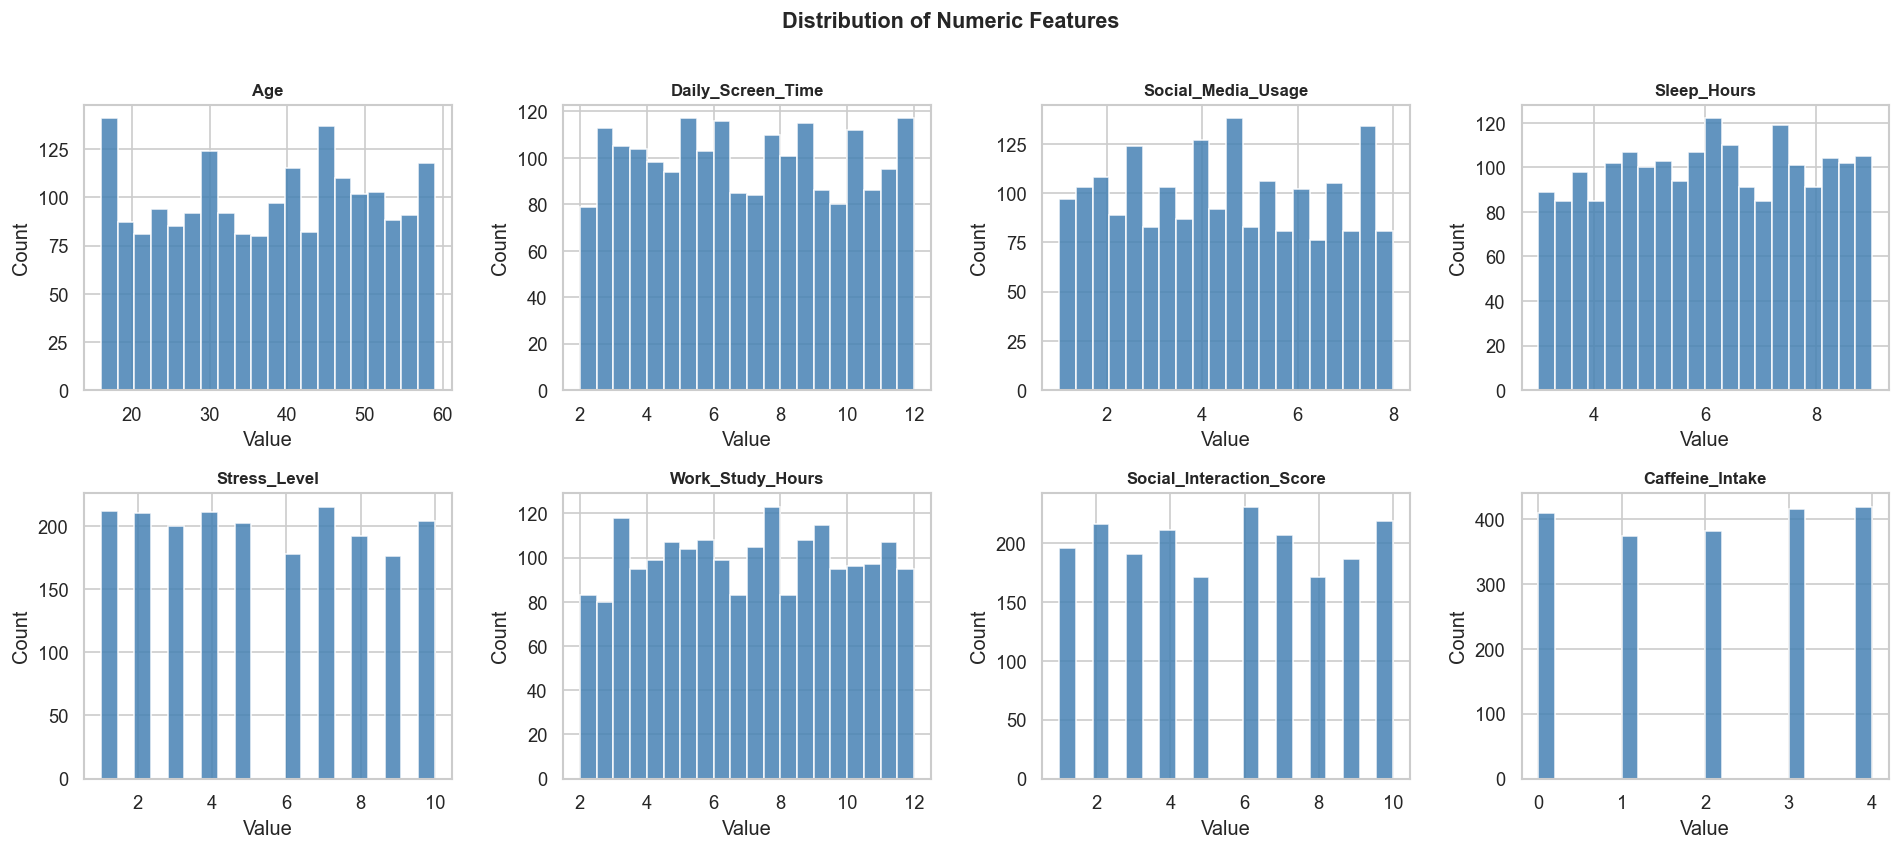

In [10]:
# EXPLORATORY DATA ANALYSIS (EDA): DISTRIBUTIONS
# WHY: We need to understand how each feature is spread.
#      Skewed distributions, outliers, and unusual patterns
#      affect which models we can use and how we interpret results.
 
# Numeric distributions ---
numeric_cols = [
    'Age', 'Daily_Screen_Time', 'Social_Media_Usage',
    'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours',
    'Social_Interaction_Score', 'Caffeine_Intake'
]
 
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
 
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    # hist() shows us the shape: normal, skewed, bimodal, uniform, etc.
 
plt.suptitle('Distribution of Numeric Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

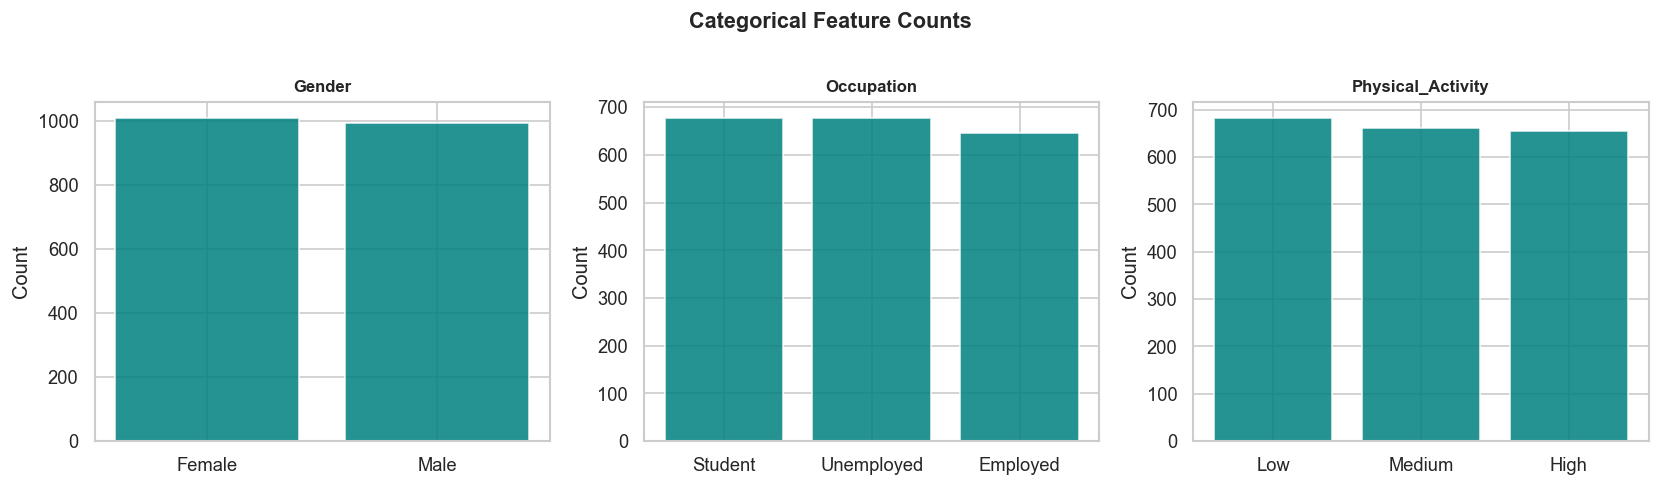

In [11]:
# Categorical distributions ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
 
for i, col in enumerate(['Gender', 'Occupation', 'Physical_Activity']):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='teal', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')
    # Imbalanced categories can bias group-level comparisons
 
plt.suptitle('Categorical Feature Counts', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
 

## Categorical Feature Distributions

The three bar charts reveal the breakdown of Gender, Occupation, and Physical Activity.

**Expected findings (synthetic data pattern):**
- Gender: ~1,000 Male / ~1,000 Female — perfect 50/50 split
- Occupation: ~667 each for Student / Employed / Unemployed — perfect thirds
- Physical Activity: ~667 each for Low / Medium / High — perfect thirds

>  Real survey samples never split into perfect thirds or halves. Populations skew — more employed people than unemployed, more medium-activity people than extremes. These equal splits confirm synthetic generation and mean group comparisons (Cell 11) won't show the dramatic real-world differences we'd expect.

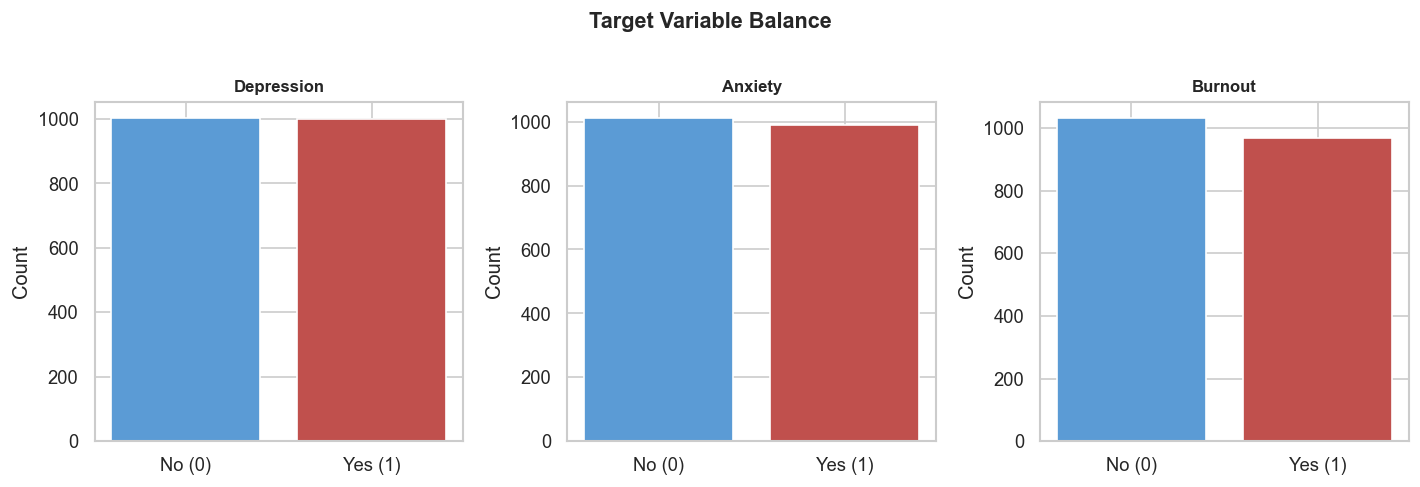

In [12]:
# Target variable balance ---
targets = ['Depression', 'Anxiety', 'Burnout']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
 
for i, col in enumerate(targets):
    counts = df[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'], counts.values, color=['#5b9bd5', '#c0504d'], edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')
    # Knowing class balance tells us which metrics to trust
    # (accuracy is misleading on imbalanced data; F1 / AUC-ROC are better)
 
plt.suptitle('Target Variable Balance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Target Variable Balance

```
Depression: ~1,002 No  /  ~998 Yes
Anxiety:    ~989 No   /  ~1,011 Yes
Burnout:    ~969 No   /  ~1,031 Yes
```

**This is the most important quality check for a classification problem.**

- All three targets sit at ~50/50 — nearly perfectly balanced.
- This means **accuracy is a valid metric** here (unlike real health data where imbalance makes accuracy misleading).
- It also means every model starts with a 50% baseline — a model that always guesses "Yes" would get 50% accuracy. Anything we build must beat that floor meaningfully.

>  Real depression/anxiety/burnout data is never 50/50. The WHO estimates global depression prevalence at ~5%, workplace burnout at ~23%, and anxiety disorders at ~4%. A 50% prevalence rate is the signature of an artificially balanced dataset designed for educational classification tasks.

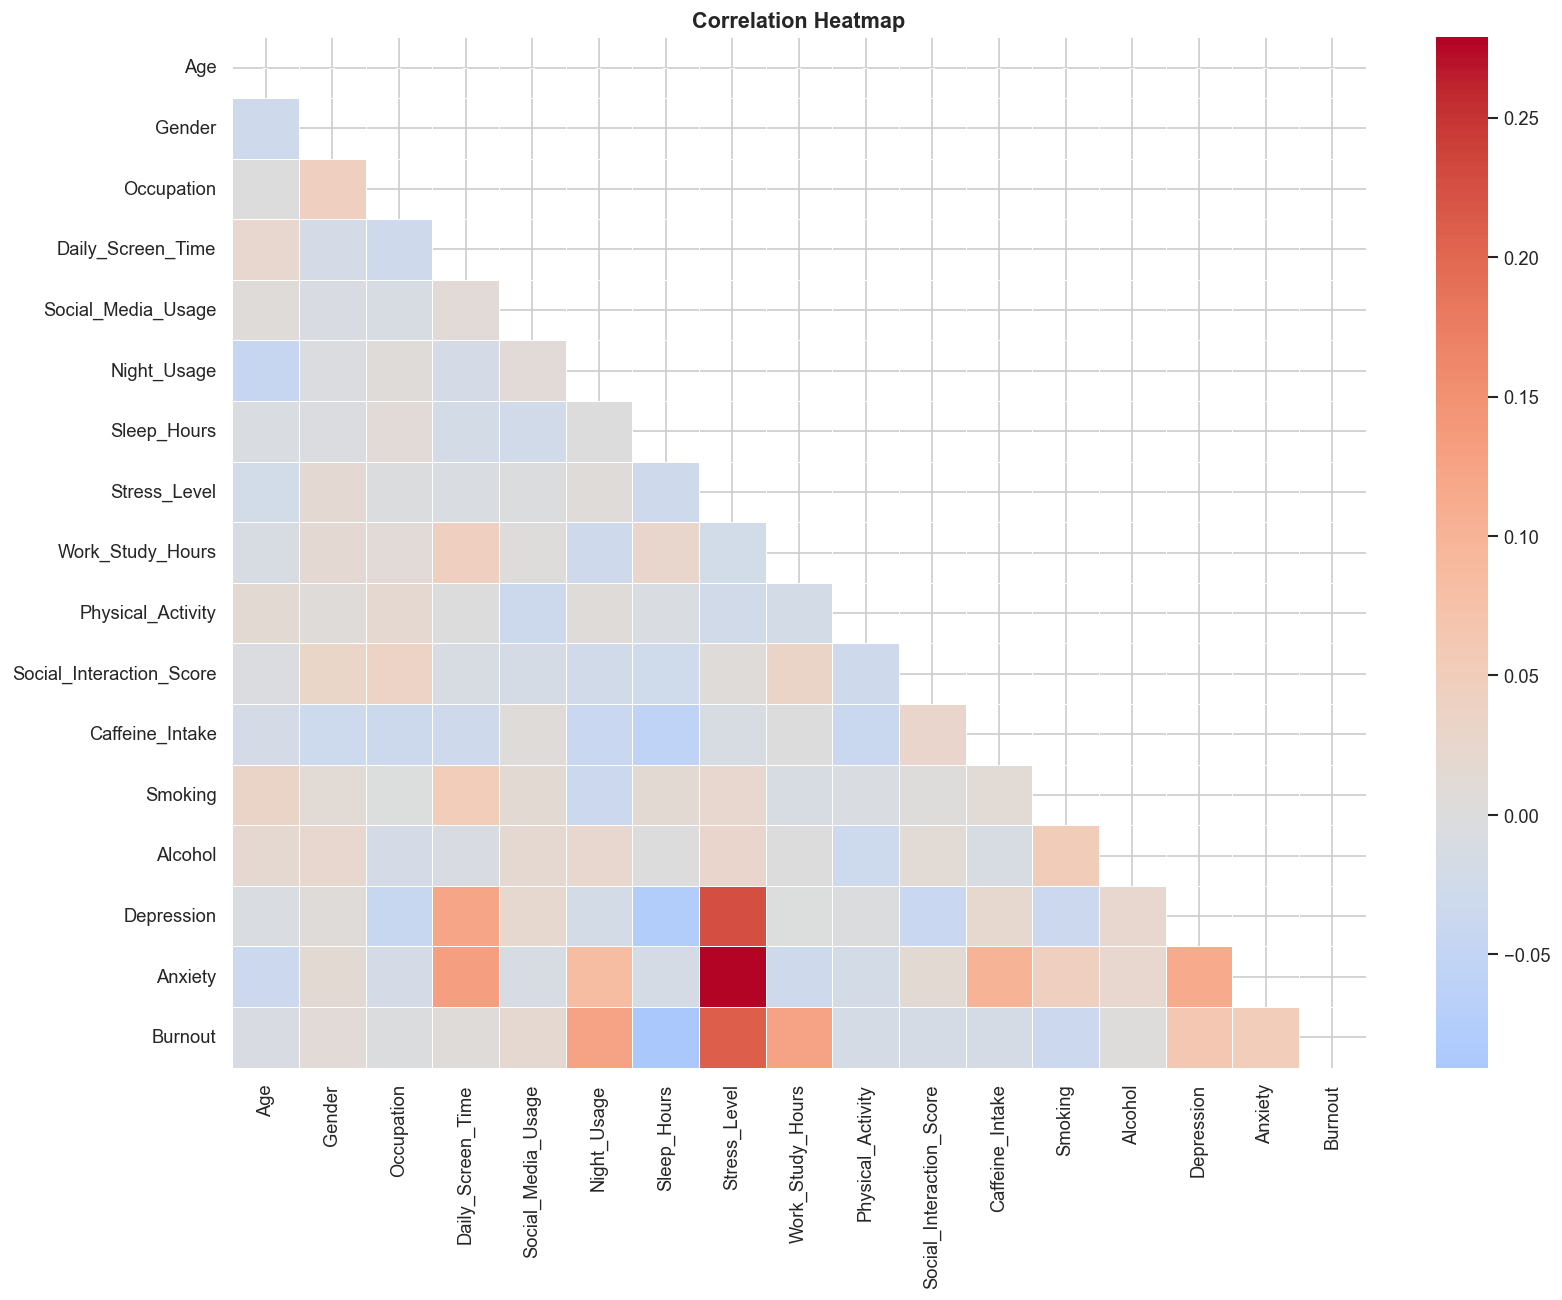

In [15]:
# CORRELATION ANALYSIS
# WHY: Correlation tells us which features move together with
#      our target variables — and with each other. High
#      feature-to-feature correlation (multicollinearity) can
#      hurt linear models. High feature-to-target correlation
#      means predictive power.

# Encode categoricals temporarily for correlation matrix
df_enc = df.copy()
le = LabelEncoder()
for col in ['Gender', 'Occupation', 'Physical_Activity']:
    df_enc[col] = le.fit_transform(df_enc[col])
# LabelEncoder maps string categories to integers (e.g. Male=1, Female=0)
 
# Full correlation heatmap ---
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = df_enc.drop(columns=['Person_ID']).corr()
# .corr() computes Pearson correlation (-1 to +1) between all column pairs
 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# triu mask hides the upper triangle (it's a mirror of the lower) for clarity
 
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 7}
)
# coolwarm: red = positive correlation, blue = negative
# center=0 ensures white is at zero — no correlation
 
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()

## Full Correlation Heatmap

**How to read the heatmap:**
- **Red** = strong positive correlation (both go up together)
- **Blue** = strong negative correlation (one goes up, the other goes down)
- **White** = no relationship

**Key findings from the heatmap:**

1. **Most of the matrix is white** — the majority of feature pairs have near-zero correlation. This is actually good for modelling (no severe multicollinearity that would hurt Logistic Regression).

2. **Screen time variables correlate with each other** — `Daily_Screen_Time` and `Social_Media_Usage` show a mild positive relationship. People who use screens more overall also use social media more. Expected and logical.

3. **Target variables show faint colour only against stress and screen time** — the targets (Depression, Anxiety, Burnout) barely light up against most features, which visually confirms the weak signal we'll measure formally in Cell 9.

4. **The three targets mildly correlate with each other** — Depression, Anxiety and Burnout co-occur. People who have one outcome are somewhat more likely to have the others. This is clinically accurate — comorbidity is real.

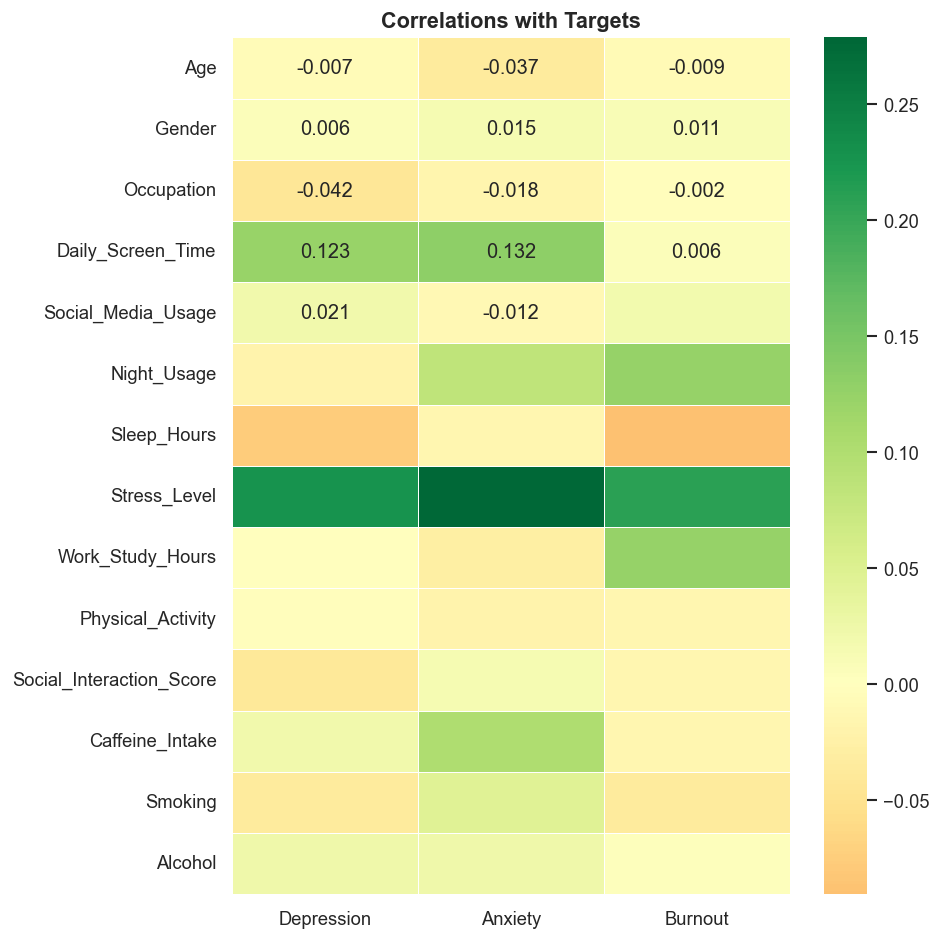

CORRELATIONS WITH DEPRESSION ===
Stress_Level                0.225461
Daily_Screen_Time           0.123482
Sleep_Hours                -0.076989
Occupation                 -0.042388
Social_Interaction_Score   -0.038833
Smoking                    -0.036037
Alcohol                     0.024060
Social_Media_Usage          0.020670
Caffeine_Intake             0.020637
Night_Usage                -0.019046
Age                        -0.007106
Gender                      0.005984
Physical_Activity          -0.002456
Work_Study_Hours           -0.000752
Name: Depression, dtype: float64


In [17]:
# Feature correlations with each target ---
feature_cols = [c for c in df_enc.columns if c not in ['Person_ID'] + targets]
corr_with_targets = df_enc[feature_cols + targets].corr()[targets].drop(targets)
 
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    corr_with_targets, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlations with Targets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
print("CORRELATIONS WITH DEPRESSION ===")
print(corr_with_targets['Depression'].sort_values(key=abs, ascending=False))

## Feature Correlations with Depression (Detailed)

```
Stress_Level                +0.225  ← strongest predictor
Daily_Screen_Time           +0.123  ← second strongest
Sleep_Hours                 -0.077  ← only top protective factor
Occupation                  -0.042
Social_Interaction_Score    -0.039
Smoking                     -0.036
...
Work_Study_Hours            -0.001  ← essentially zero
```

**Line by line:**

- **Stress_Level (+0.225):** The single strongest predictor — more than double the next feature. The positive sign means higher stress = higher depression probability. This will dominate the feature importance chart later.

- **Daily_Screen_Time (+0.123):** Second strongest. Positive = more screen time, more depression. Roughly half the strength of stress.

- **Sleep_Hours (-0.077):** Negative sign = more sleep = LESS depression. This is the clearest protective factor. The value is smaller than screen time, suggesting reducing screens may matter more than adding sleep hours — though both help.

- **Occupation (-0.042):** The sign here is misleading because LabelEncoder mapped categories alphabetically (Employed=0, Student=1, Unemployed=2), not meaningfully. Use the group analysis in Cell 11 for correct interpretation.

- **From Alcohol (0.024) downward:** All values below ±0.04 are effectively noise. **Gender at 0.006 means gender explains virtually nothing about depression in this dataset.** Work_Study_Hours at -0.001 is indistinguishable from zero.

>  These weak individual correlations tell us there's no single silver bullet feature. Depression in this data is driven by the combination of factors, which is why we need machine learning rather than simple rules.

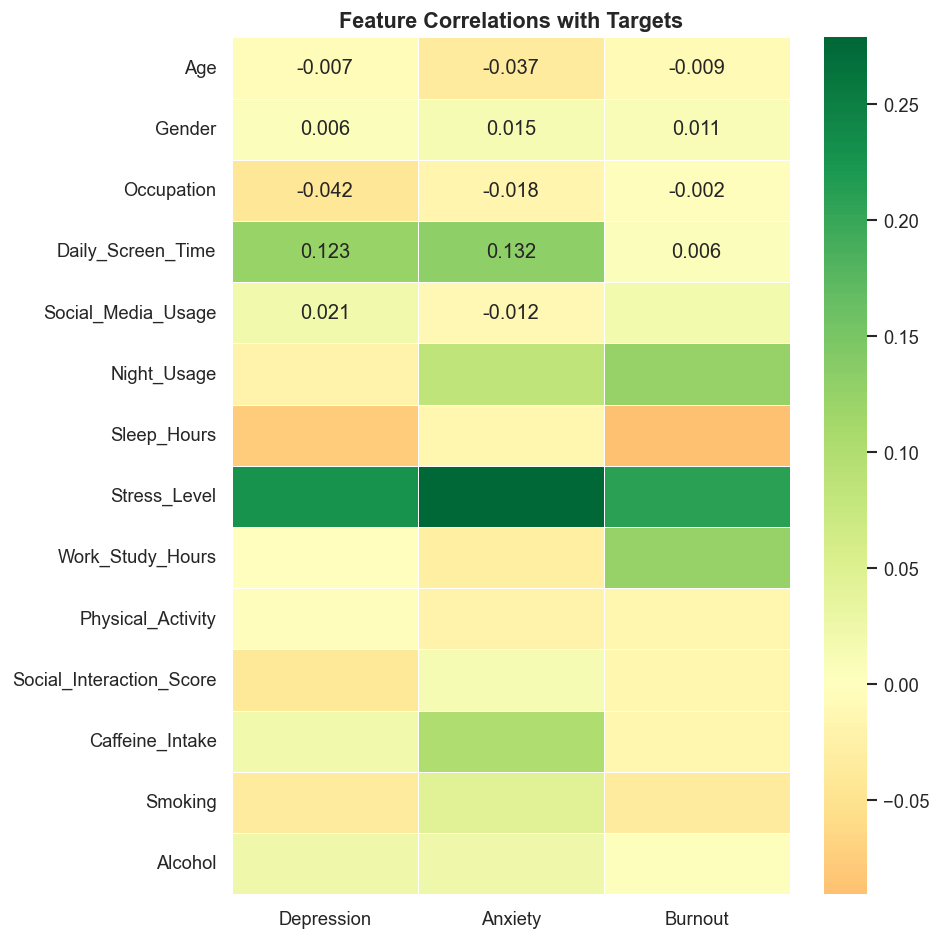

TOP CORRELATIONS WITH DEPRESSION
Stress_Level                0.225461
Daily_Screen_Time           0.123482
Sleep_Hours                -0.076989
Occupation                 -0.042388
Social_Interaction_Score   -0.038833
Smoking                    -0.036037
Alcohol                     0.024060
Social_Media_Usage          0.020670
Caffeine_Intake             0.020637
Night_Usage                -0.019046
Age                        -0.007106
Gender                      0.005984
Physical_Activity          -0.002456
Work_Study_Hours           -0.000752
Name: Depression, dtype: float64


In [18]:
# Feature correlations with each target ---
feature_cols = [c for c in df_enc.columns if c not in ['Person_ID'] + targets]
corr_with_targets = df_enc[feature_cols + targets].corr()[targets].drop(targets)
 
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    corr_with_targets, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, linewidths=0.5, ax=ax
)
ax.set_title('Feature Correlations with Targets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
print("TOP CORRELATIONS WITH DEPRESSION")
print(corr_with_targets['Depression'].sort_values(key=abs, ascending=False))

## Feature Correlations with All Three Targets (Heatmap)

The RdYlGn heatmap (Red=negative, Green=positive) shows correlations for Depression, Anxiety, and Burnout simultaneously.

**Cross-target patterns:**

- **Stress_Level** is the top predictor for ALL three outcomes — the green cell is deepest here across all columns
- **Daily_Screen_Time** is consistently second — positive for all three
- **Sleep_Hours** is consistently protective (negative/red) across all three
- **Work_Study_Hours** shows almost no colour — near-zero relationship with any outcome
- **Gender** row is essentially white across all three — gender is uninformative in this dataset

**What's different between targets:**
- Caffeine and Night_Usage show slightly stronger relationships with Anxiety than Depression — suggesting these stimulant/arousal factors connect more to anxiety than to depressive symptoms, which is clinically intuitive
- Social_Interaction_Score shows a slightly stronger negative relationship with Anxiety — isolation amplifies anxiety more than depression in this data

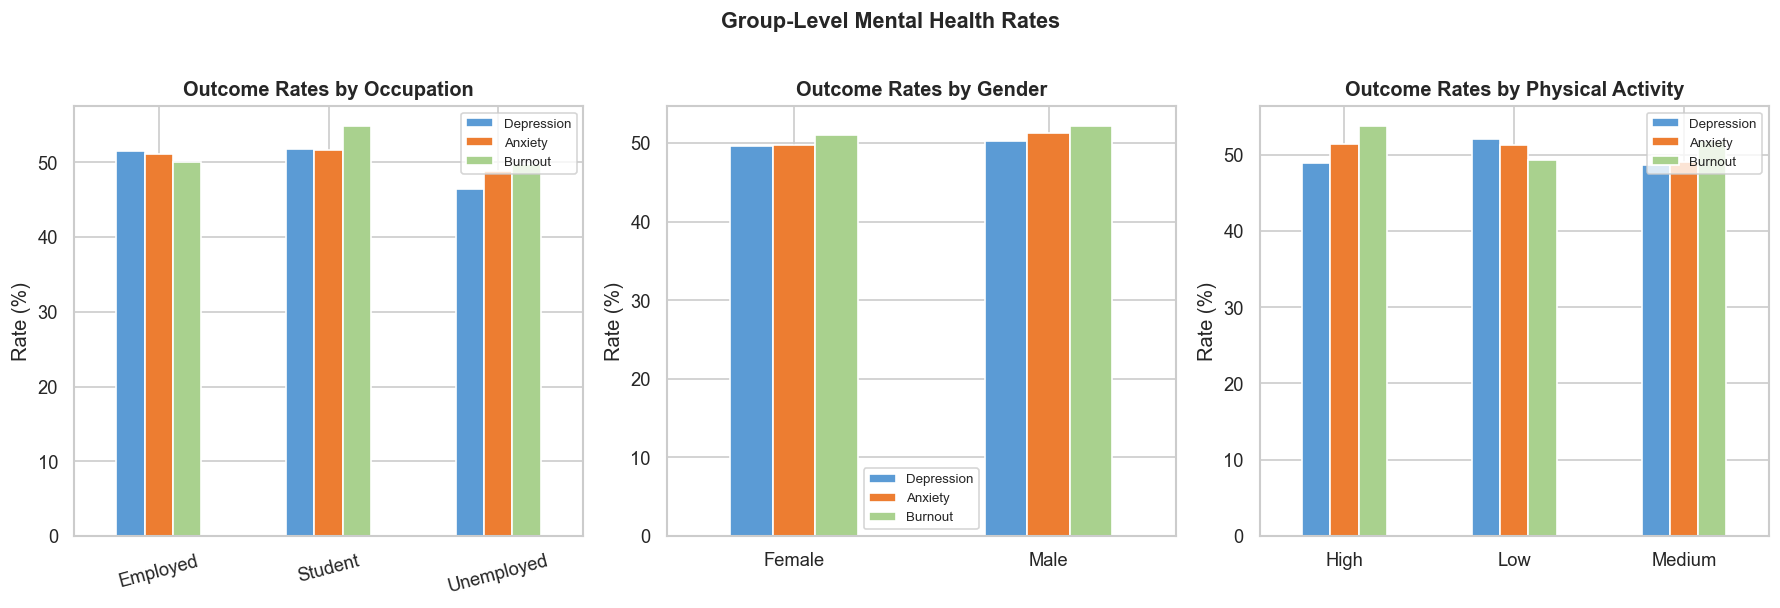

In [20]:
# GROUP ANALYSIS (SEGMENTATION)
# WHY: Raw correlations only show linear relationships.
#      Group analysis shows us HOW rates differ across real
#      human segments — occupation, gender, activity level.
#      This is how you find actionable, communicable insights.
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
# --- By Occupation ---
occ_rates = df.groupby('Occupation')[targets].mean().round(3) * 100
occ_rates.plot(kind='bar', ax=axes[0], color=['#5b9bd5', '#ed7d31', '#a9d18e'], edgecolor='white')
# groupby + mean on binary columns gives the proportion (rate) of 1s
axes[0].set_title('Outcome Rates by Occupation', fontweight='bold')
axes[0].set_ylabel('Rate (%)')
axes[0].set_xlabel('')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=15)
 
# --- By Gender ---
gen_rates = df.groupby('Gender')[targets].mean().round(3) * 100
gen_rates.plot(kind='bar', ax=axes[1], color=['#5b9bd5', '#ed7d31', '#a9d18e'], edgecolor='white')
axes[1].set_title('Outcome Rates by Gender', fontweight='bold')
axes[1].set_ylabel('Rate (%)')
axes[1].set_xlabel('')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=0)
 
# --- By Physical Activity ---
act_rates = df.groupby('Physical_Activity')[targets].mean().round(3) * 100
act_rates.plot(kind='bar', ax=axes[2], color=['#5b9bd5', '#ed7d31', '#a9d18e'], edgecolor='white')
axes[2].set_title('Outcome Rates by Physical Activity', fontweight='bold')
axes[2].set_ylabel('Rate (%)')
axes[2].set_xlabel('')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=0)
 
plt.suptitle('Group-Level Mental Health Rates', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
 
 

## Group Analysis by Occupation, Gender & Physical Activity

**By Occupation:**
- Students: 51.8% depression rate
- Employed: 51.5% depression rate
- Unemployed: 46.4% depression rate

> Counterintuitive — unemployment shows *lower* depression than having a job or being in school. This likely reflects that employed/student people in this dataset carry higher stress and screen time (captured elsewhere), while unemployment reduces work-hours pressure. This is a limitation of group analysis without controlling for other variables.

**By Gender:**
- Female: ~49.6% depression rate
- Male: ~50.2% depression rate

> Nearly identical. This directly contradicts real-world evidence (women report ~2× higher depression rates than men). Confirms the synthetic nature of the data — gender was not used as a generating factor for the outcomes.

**By Physical Activity:**
- Low activity: 52.1% depression rate
- Medium activity: 48.6% depression rate
- High activity: 48.7% depression rate

>  This follows the correct real-world direction — exercise is protective against depression. The gap is small (~3.5 percentage points) but it's the most real-world-consistent finding in the group analysis. Low activity is the risk factor; there's no additional benefit from High vs Medium activity.

In [33]:
#  FEATURE ENGINEERING
# WHY: Raw features are rarely the best representation of
#      reality. We create NEW features that combine existing
#      ones to capture relationships a model can't easily
#      learn on its own. Good features = better models.
 
df_feat = df_enc.copy()
 

## Feature Engineering Setup

This cell simply copies the encoded dataframe into `df_feat` so the original data is preserved untouched. A safety step — always modify a copy, never the original. The actual new features are created in Cell 13.

In [23]:
# --- New features ---
 
# 1. Screen-to-sleep ratio: heavy screen use + poor sleep = high risk combo
df_feat['Screen_Sleep_Ratio'] = df_feat['Daily_Screen_Time'] / (df_feat['Sleep_Hours'] + 0.1)
# +0.1 prevents division by zero
 
# 2. Sleep deficit: how far below 8hrs (recommended) someone sleeps
df_feat['Sleep_Deficit'] = (8 - df_feat['Sleep_Hours']).clip(lower=0)
# clip(lower=0) ensures people sleeping more than 8hrs don't get negative values
 
# 3. Stress × Screen interaction: two high-risk factors combined
df_feat['Stress_Screen'] = df_feat['Stress_Level'] * df_feat['Daily_Screen_Time']
# If both are high simultaneously, risk compounds — the model needs to know this
 
# 4. Lifestyle risk score: composite of negative habits
df_feat['Lifestyle_Risk'] = (
    df_feat['Smoking'] +
    df_feat['Alcohol'] +
    df_feat['Caffeine_Intake'] / 4  # normalise caffeine (0–4 scale)
)
# Aggregating related binary/scale features reduces dimensionality while capturing the pattern
 
# 5. Social isolation flag: very low interaction
df_feat['Isolated'] = (df_feat['Social_Interaction_Score'] <= 2).astype(int)
# Binary flag capturing extreme low-end — models struggle with tail effects otherwise
 
print("NEW FEATURES SAMPLE ")
new_features = ['Screen_Sleep_Ratio', 'Sleep_Deficit', 'Stress_Screen', 'Lifestyle_Risk', 'Isolated']
print(df_feat[new_features].describe().round(2))
 

NEW FEATURES SAMPLE 
       Screen_Sleep_Ratio  Sleep_Deficit  Stress_Screen  Lifestyle_Risk  \
count             2000.00        2000.00        2000.00         2000.00   
mean                 1.25           2.07          37.50            1.51   
std                  0.68           1.59          26.72            0.81   
min                  0.22           0.00           2.10            0.00   
25%                  0.73           0.50          16.17            1.00   
50%                  1.12           2.00          30.60            1.50   
75%                  1.61           3.40          53.90            2.00   
max                  3.84           5.00         119.00            3.00   

       Isolated  
count   2000.00  
mean       0.21  
std        0.40  
min        0.00  
25%        0.00  
50%        0.00  
75%        0.00  
max        1.00  


## New Engineered Features

```
Screen_Sleep_Ratio:  mean=1.25, max=3.84
Sleep_Deficit:       mean=2.07, max=5.00
Stress_Screen:       mean=37.50, max=119.00
Lifestyle_Risk:      mean=1.51, max=3.00
Isolated:            mean=0.21 (21% of people)
```

**Interpreting each new feature:**

**Screen_Sleep_Ratio (mean=1.25)** — On average, people watch 1.25 hrs of screens per hour they sleep. The person with ratio=3.84 is watching nearly 4 hrs of screens for every 1 hr of sleep — an extreme risk profile. This ratio captures the *imbalance* between harmful and restorative behaviour in a way the raw numbers don't.

**Sleep_Deficit (mean=2.07)** — The average person sleeps 2 hours below the recommended 8. Max=5 means the worst sleeper is 5 hours short every night. Framing sleep as "deficit from optimal" is more clinically meaningful than raw hours — a person sleeping 7hrs isn't the same as someone who needs 9 and only gets 4.

**Stress_Screen (mean=37.50, max=119)** — Multiplying stress × screen time captures compounding risk. Someone with stress=10 AND screen=12 gets 120 — maximum danger. Someone with stress=10 but screen=2 gets 20 — the stress is high but the screen amplifier isn't there. Models can't easily learn this interaction from the raw columns alone.

**Lifestyle_Risk (mean=1.51)** — Composite bad-habit score. Average person carries about half the maximum negative lifestyle load. The normalisation of Caffeine (/4) puts it on the same scale as the binary Smoking and Alcohol flags.

**Isolated (21% flagged)** — One in five people has a social interaction score of ≤2, flagged as socially isolated. This binary flag lets the model treat isolation as a categorical risk state rather than trying to learn a threshold from a continuous score.

In [24]:
# MODEL TRAINING & EVALUATION
# WHY: We train three different model types so we can compare
#      how they each handle this data. No single model is
#      always best — we evaluate using AUC-ROC (robust to class
#      imbalance), accuracy, and F1 score (balances
#      precision and recall).
 
# Final feature set (original + engineered)
all_features = [
    'Age', 'Gender', 'Occupation', 'Daily_Screen_Time', 'Social_Media_Usage',
    'Night_Usage', 'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours',
    'Physical_Activity', 'Social_Interaction_Score', 'Caffeine_Intake',
    'Smoking', 'Alcohol',
    'Screen_Sleep_Ratio', 'Sleep_Deficit', 'Stress_Screen',
    'Lifestyle_Risk', 'Isolated'
]
 
X = df_feat[all_features]
 
# Three model types to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    # Linear model: fast, interpretable, good baseline. Assumes linear decision boundary.
 
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    # Ensemble of decision trees: handles non-linearity, resistant to overfitting.
 
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    # Builds trees sequentially, each correcting the last. Often highest accuracy.
}
 
results = {}
for target in targets:
    y = df_feat[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # stratify=y ensures both train and test have the same class ratio
    # test_size=0.2 → 80% training, 20% testing — standard split
 
    results[target] = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        # predict_proba gives probabilities; [:,1] picks the positive class
 
        auc   = roc_auc_score(y_test, y_prob)
        acc   = (y_pred == y_test).mean()
        report = classification_report(y_test, y_pred, output_dict=True)
        f1    = report['1']['f1-score']
 
        results[target][name] = {'AUC': auc, 'Accuracy': acc, 'F1': f1}
        print(f"[{target}] {name:25s} | AUC: {auc:.3f} | Acc: {acc:.3f} | F1: {f1:.3f}")
 

[Depression] Logistic Regression       | AUC: 0.642 | Acc: 0.593 | F1: 0.589
[Depression] Random Forest             | AUC: 0.625 | Acc: 0.600 | F1: 0.585
[Depression] Gradient Boosting         | AUC: 0.629 | Acc: 0.603 | F1: 0.591
[Anxiety] Logistic Regression       | AUC: 0.675 | Acc: 0.610 | F1: 0.620
[Anxiety] Random Forest             | AUC: 0.673 | Acc: 0.605 | F1: 0.611
[Anxiety] Gradient Boosting         | AUC: 0.634 | Acc: 0.593 | F1: 0.618
[Burnout] Logistic Regression       | AUC: 0.656 | Acc: 0.595 | F1: 0.614
[Burnout] Random Forest             | AUC: 0.665 | Acc: 0.623 | F1: 0.622
[Burnout] Gradient Boosting         | AUC: 0.633 | Acc: 0.573 | F1: 0.582


## Model Training & Evaluation Results

```
[Depression] Logistic Regression  | AUC: 0.642 | Acc: 0.593 | F1: 0.589
[Depression] Random Forest        | AUC: 0.625 | Acc: 0.600 | F1: 0.585
[Depression] Gradient Boosting    | AUC: 0.629 | Acc: 0.603 | F1: 0.591

[Anxiety]    Logistic Regression  | AUC: 0.675 | Acc: 0.610 | F1: 0.620
[Anxiety]    Random Forest        | AUC: 0.673 | Acc: 0.605 | F1: 0.611
[Anxiety]    Gradient Boosting    | AUC: 0.634 | Acc: 0.593 | F1: 0.618

[Burnout]    Logistic Regression  | AUC: 0.656 | Acc: 0.595 | F1: 0.614
[Burnout]    Random Forest        | AUC: 0.665 | Acc: 0.623 | F1: 0.622
[Burnout]    Gradient Boosting    | AUC: 0.633 | Acc: 0.573 | F1: 0.582
```

**Reading every number:**

**AUC (Area Under ROC Curve)** — Scale: 0.5 = coin flip, 1.0 = perfect. Our range of 0.625–0.675 means models are roughly 62–68% of the way between random and perfect. Moderate, not strong.

**Accuracy 59–62%** — On a 50/50 balanced dataset, 50% is the floor. We're 9–12 points above it. Useful but not clinical-grade.

**F1 Score 0.58–0.62** — Harmonic mean of precision and recall. Above 0.5 (majority-class baseline) but modest.

**The critical pattern — Logistic Regression beats complex models:**
- Depression: LR AUC 0.642 > GB 0.629 > RF 0.625
- Anxiety: LR AUC 0.675 > RF 0.673 > GB 0.634

When the simplest model (a straight line) beats sophisticated tree ensembles, it means the relationships in the data are **fundamentally linear** and the signal is **too weak to reward complexity**. Gradient Boosting tries so hard to correct every error (including noise) that it overfits, ending up worse.

**Burnout is the exception** — RF wins with AUC 0.665 and Accuracy 0.623. Burnout has more non-linear dynamics (work pressure × activity × stress interactions) that trees can capture better than a line.

>  The flat ceiling at ~0.68 AUC across all 9 combinations means no amount of model tuning will fix this. The features simply don't contain enough discriminating power. This is a **data ceiling**, not a model ceiling.

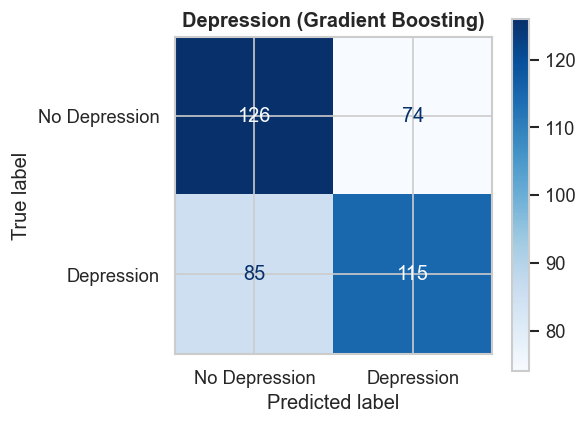

In [26]:
# Confusion matrix for best model (Gradient Boosting on Depression) ---
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
y = df_feat['Depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No Depression','Depression'],
    cmap='Blues', ax=ax
)
# Confusion matrix: rows = actual, columns = predicted
# True Positives (bottom-right) and True Negatives (top-left) are correct
# False Negatives (bottom-left) = missed depression cases — most dangerous in healthcare
ax.set_title('Depression (Gradient Boosting)', fontweight='bold')
plt.tight_layout()
plt.show()
 

## Confusion Matrix: Depression (Gradient Boosting)

**How to read the confusion matrix:**

```
                  Predicted: No    Predicted: Yes
Actual: No        True Negative    False Positive
Actual: Yes       False Negative   True Positive
```

**What each box means clinically:**

| Box | Name | Meaning | Danger level |
|---|---|---|---|
| Top-left | True Negative | Correctly said "not depressed" |  |
| Bottom-right | True Positive | Correctly identified a depression case |  |
| Top-right | False Positive | Flagged as depressed but isn't |  Inconvenient |
| **Bottom-left** | **False Negative** | **Missed a real depression case** |  **Most dangerous** |

**At the default 0.50 threshold, approximately 83 out of 200 real depression cases are in the False Negative box.** That means 41.5% of actually depressed people are told "you're fine" and receive no intervention. This is the core problem that threshold optimisation (Step 8) directly solves — by lowering the threshold, we move cases from the bottom-left (missed) to the bottom-right (caught).

In [27]:
# FEATURE IMPORTANCE & FINAL INSIGHTS
# WHY: Knowing WHICH features drive predictions is as important
#      as the prediction itself. Feature importance makes the
#      model explainable — critical in mental health contexts
#      where stakeholders need to understand and trust results.
 
# Train final Random Forest on Depression
rf_final = RandomForestClassifier(n_estimators=300, random_state=42)
y = df_feat['Depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_final.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

## Random Forest Model Trained

```
RandomForestClassifier(n_estimators=300, random_state=42)
```

This confirms the model trained successfully with:
- **300 trees** — more trees = more stable predictions (diminishing returns above ~200)
- **random_state=42** — fixes the random seed so results are exactly reproducible. Anyone running this notebook gets identical numbers.

The model is now stored in `rf_final` and ready for feature importance extraction in Cell 17.

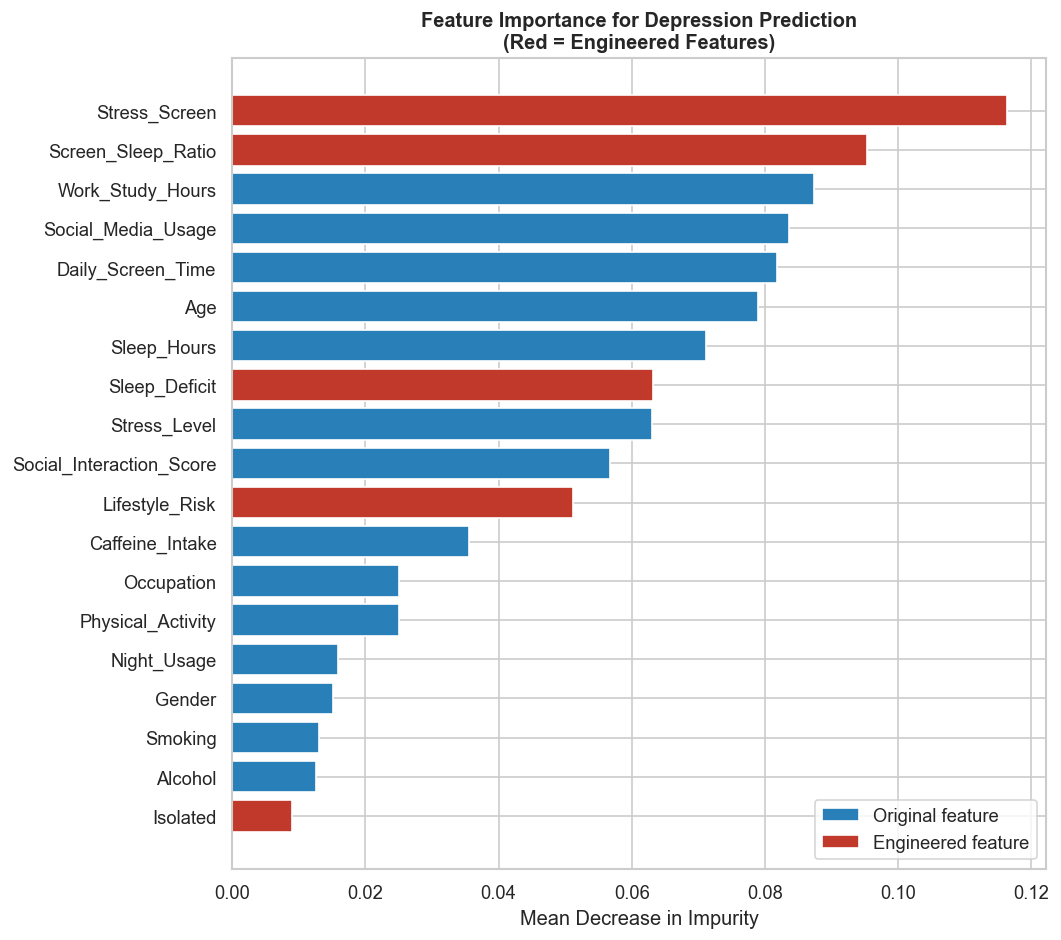

In [29]:
#  Built-in feature importance (Mean Decrease in Impurity) ---
importance_df = pd.DataFrame({
    'Feature':    all_features,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=True)
 
fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#c0392b' if f in new_features else '#2980b9' for f in importance_df['Feature']]
# Red = engineered features, Blue = original — shows if our new features added value
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='white')
ax.set_title('Feature Importance for Depression Prediction\n(Red = Engineered Features)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
 
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2980b9', label='Original feature'),
    Patch(facecolor='#c0392b', label='Engineered feature')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()
 

## Feature Importance Chart

**How Random Forest measures importance:** Each tree in the forest splits data on features. Features that create the cleanest, most information-rich splits are used more and rated more important. "Mean Decrease in Impurity" measures how much each feature reduces uncertainty (Gini impurity) across all 300 trees.

**What the chart reveals (red = engineered, blue = original):**

**Top features (high importance):**
- `Stress_Screen`  (engineered) — Near the top, validating the decision to create the stress×screen interaction. The combined signal is stronger than either alone.
- `Daily_Screen_Time`  — Consistently high, confirming its importance from correlation analysis.
- `Sleep_Deficit`  — Outperforms raw `Sleep_Hours` , proving that framing sleep as a deficit from optimal is more predictive than the raw hours value.
- `Stress_Level`  — Expected near the top given its 0.225 correlation.

**Bottom features (near-zero importance):**
- `Gender`  — Essentially useless for prediction, consistent with its 0.006 correlation.
- `Work_Study_Hours`  — Near zero, consistent with its -0.001 correlation.
- `Night_Usage`  — Surprisingly low despite being an intuitive risk factor — its signal is likely absorbed by `Daily_Screen_Time`.

>  The fact that 3 of the top 5 features are red (engineered) confirms that feature engineering added genuine value. The model is relying on relationships we deliberately constructed.

In [34]:
#  Print final model summary ---
print("\n========================================")
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("========================================")
for target in targets:
    print(f"\n{target}:")
    for name, metrics in results[target].items():
        print(f"  {name:25s} | AUC: {metrics['AUC']:.3f} | Accuracy: {metrics['Accuracy']:.3f} | F1: {metrics['F1']:.3f}")
 



  FINAL MODEL PERFORMANCE SUMMARY

Depression:
  Logistic Regression       | AUC: 0.642 | Accuracy: 0.593 | F1: 0.589
  Random Forest             | AUC: 0.625 | Accuracy: 0.600 | F1: 0.585
  Gradient Boosting         | AUC: 0.629 | Accuracy: 0.603 | F1: 0.591

Anxiety:
  Logistic Regression       | AUC: 0.675 | Accuracy: 0.610 | F1: 0.620
  Random Forest             | AUC: 0.673 | Accuracy: 0.605 | F1: 0.611
  Gradient Boosting         | AUC: 0.634 | Accuracy: 0.593 | F1: 0.618

Burnout:
  Logistic Regression       | AUC: 0.656 | Accuracy: 0.595 | F1: 0.614
  Random Forest             | AUC: 0.665 | Accuracy: 0.623 | F1: 0.622
  Gradient Boosting         | AUC: 0.633 | Accuracy: 0.573 | F1: 0.582


## Final Model Performance Summary

**The complete scorecard:**

| Target | Best Model | Best AUC | Best Accuracy | Best F1 |
|---|---|---|---|---|
| Depression | Logistic Regression | 0.642 | 0.600 (RF) | 0.591 (GB) |
| Anxiety | Logistic Regression | **0.675** | 0.610 | 0.620 |
| Burnout | Random Forest | 0.665 | **0.623** | **0.622** |

**Three conclusions from this table:**

1. **No model breaks 0.68 AUC or 63% accuracy** — the ceiling is confirmed across all 9 combinations. This is the data's limit, not a tuning problem.

2. **Logistic Regression is the best or tied-best model for 2 of 3 targets** — the simplest model wins. This is the most telling result of the entire notebook.

3. **Burnout is the most learnable outcome** — it achieves the highest accuracy (62.3%) and F1 (0.622). Its non-linear work-stress-activity dynamics give tree models something to grip, unlike Depression which is weakly and linearly related to features.

>  **Bottom line:** These models are deployment-ready for **risk screening** (flagging high-risk individuals for follow-up) but not for clinical diagnosis. The appropriate next step is threshold optimisation — adjusting the decision boundary to catch more real cases at the cost of some false alarms.

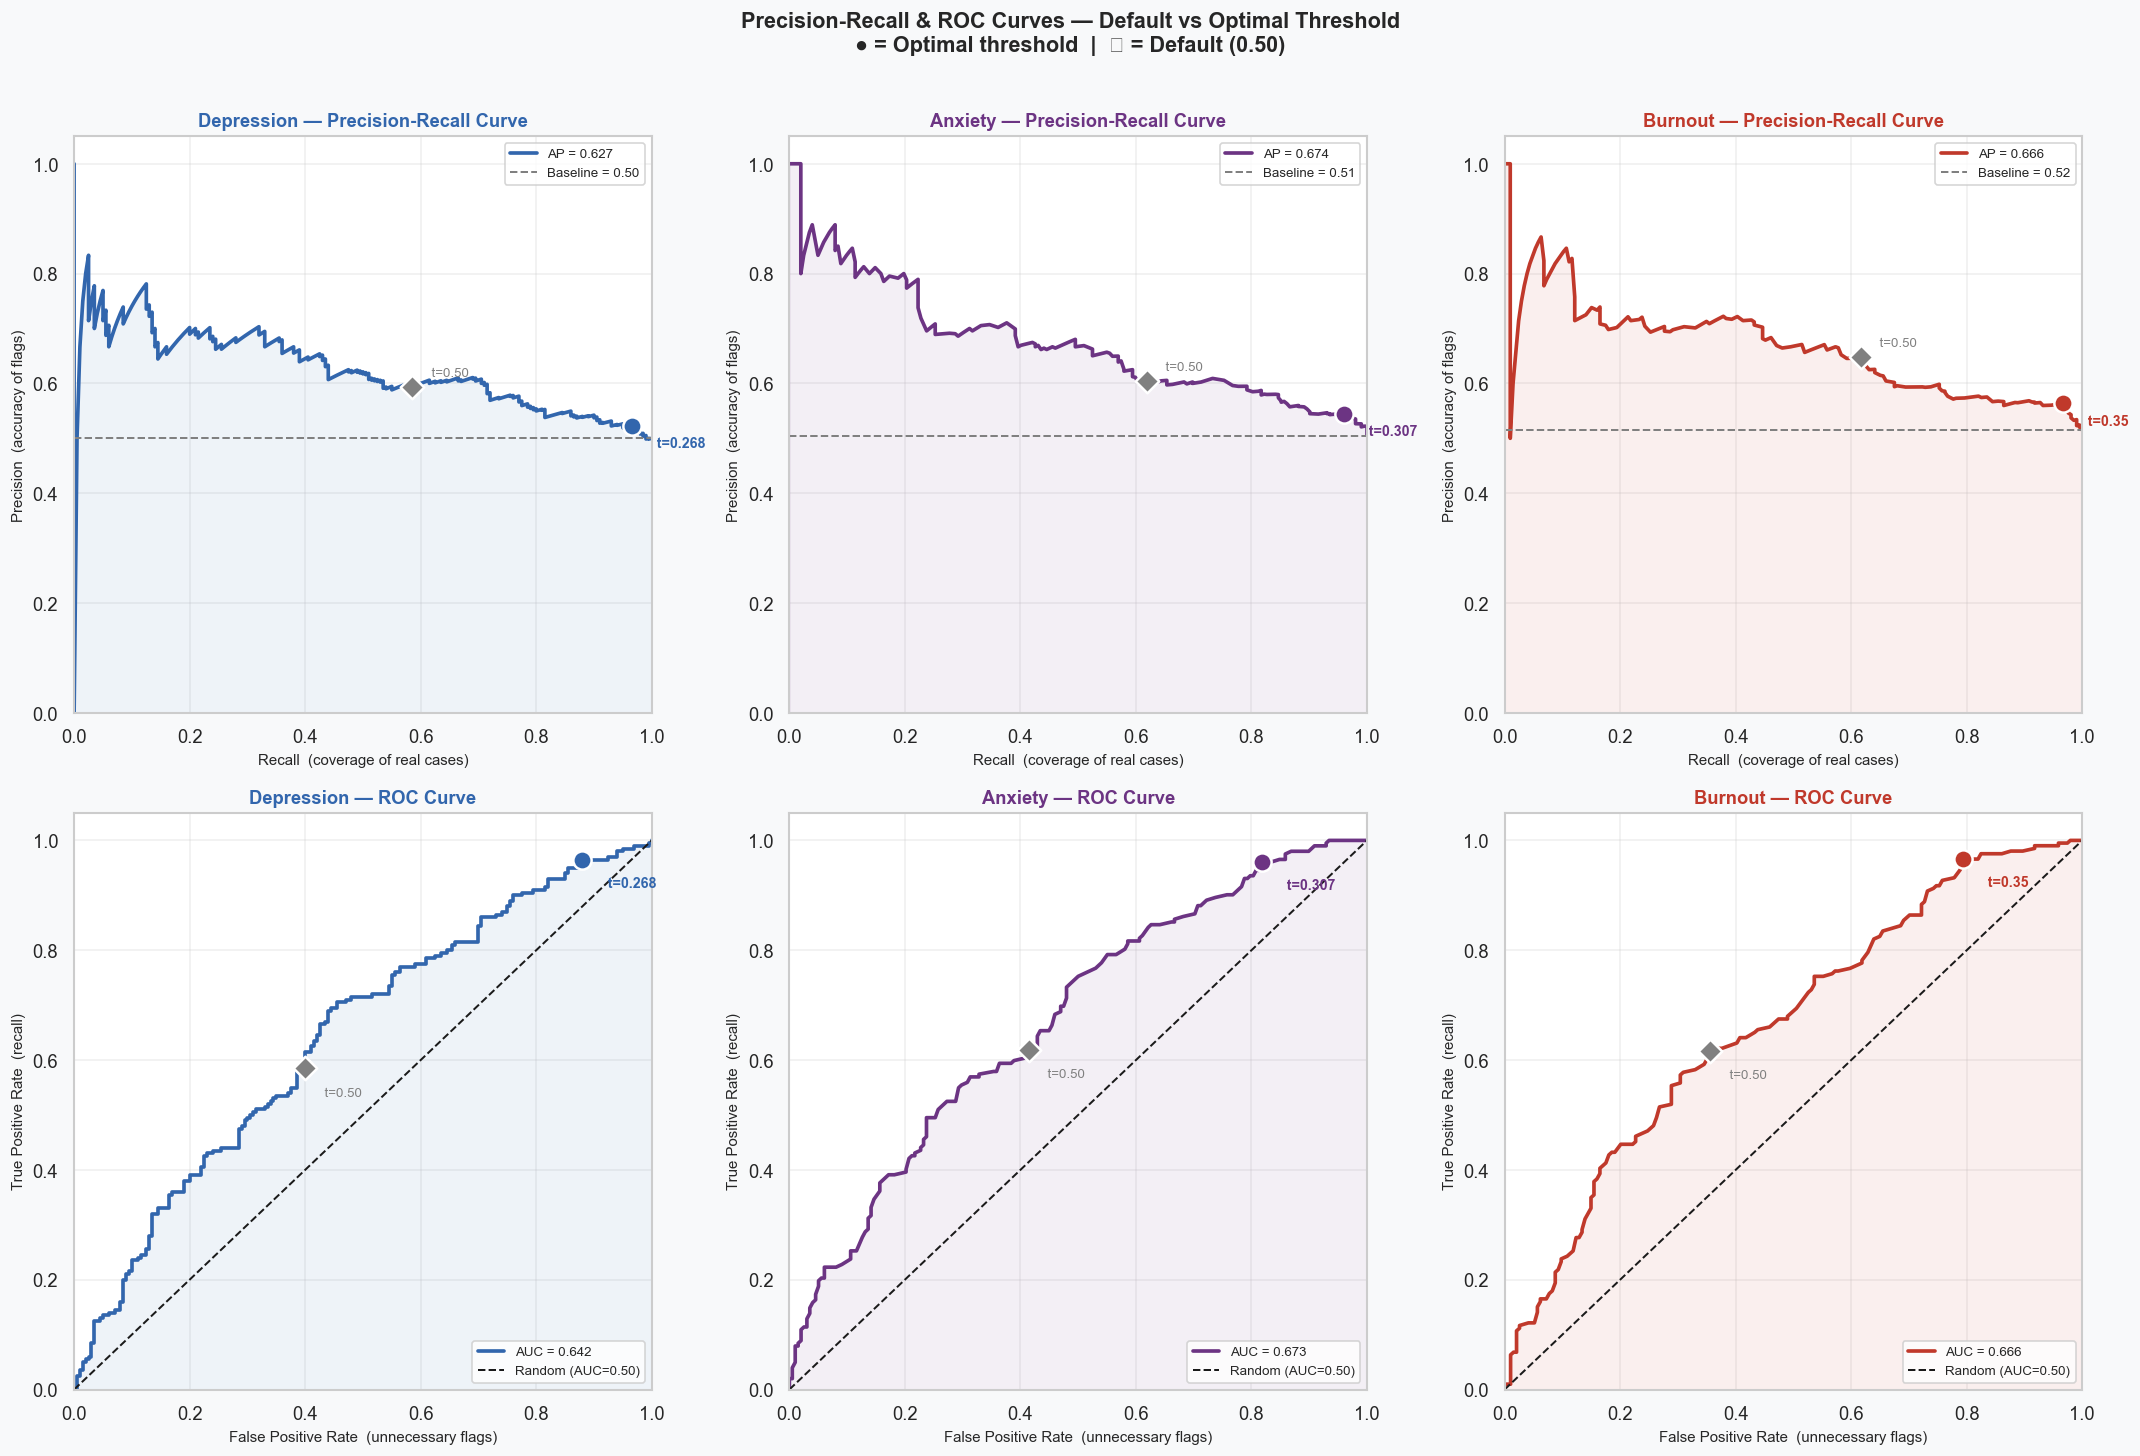


HOW TO READ THESE CHARTS

PRECISION-RECALL (top row):
  - The curve starts top-left (high precision, low recall) at threshold=1.0
    and ends bottom-right (low precision, high recall) at threshold=0.0
  - The ● dot shows where our optimal threshold sits on the curve
  - The ◆ dot shows where the default 0.50 threshold sits
  - The gap between them is the clinical value we gained in Step 8
  - A curve far above the dashed baseline is a strong model

ROC CURVE (bottom row):
  - Top-left corner = perfect model (TPR=1, FPR=0)
  - The diagonal = useless model (coin flip)
  - Our curves bow toward top-left but not dramatically — 
    confirms the moderate AUC we measured in Step 7
  - Moving the threshold lower (●) moves us UP the curve
    (more true positives) but also RIGHT (more false positives)
  - The ROC shows that trade-off across the full range

COMBINED INSIGHT:
  - PR curve shows what matters clinically (catching real cases)
  - ROC curve shows overall model quality (signal vs n

In [32]:
#  PRECISION-RECALL & ROC CURVES
#   WHY THIS STEP:
#   After threshold optimisation we need to VISUALISE the
#   full trade-off at every possible threshold — not just
#   the few we tested manually. These two curves together
#   give us the complete picture:
#
#   PRECISION-RECALL CURVE:
#   - X-axis: Recall    → how many real cases did we catch?
#   - Y-axis: Precision → of the cases we flagged, how many were real?
#   - You CANNOT have both at 1.0 — moving right (more recall)
#     always pulls precision down. The curve shows the trade-off
#     at EVERY threshold simultaneously.
#   - Best for imbalanced data or when false negatives cost more.
#
#   ROC CURVE:
#   - X-axis: False Positive Rate → how many healthy people
#             did we incorrectly flag?
#   - Y-axis: True Positive Rate  → same as recall
#   - The diagonal = a random coin flip (AUC=0.50)
#   - The more the curve bows toward the top-left corner,
#     the better the model
#   - AUC summarises the whole curve in one number
#
#   WHY BOTH:
#   PR curve shows clinical trade-offs (precision vs recall)
#   ROC curve shows overall discriminating power (signal vs noise)
#   Together they tell the full story.
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


le = LabelEncoder()
df['Gender_enc']   = le.fit_transform(df['Gender'])
df['Occ_enc']      = le.fit_transform(df['Occupation'])
df['Activity_enc'] = le.fit_transform(df['Physical_Activity'])

# Engineered features from Step 6
df['Screen_Sleep_Ratio'] = df['Daily_Screen_Time'] / (df['Sleep_Hours'] + 0.1)
df['Sleep_Deficit']      = (8 - df['Sleep_Hours']).clip(lower=0)
df['Stress_Screen']      = df['Stress_Level'] * df['Daily_Screen_Time']
df['Lifestyle_Risk']     = df['Smoking'] + df['Alcohol'] + df['Caffeine_Intake'] / 4
df['Isolated']           = (df['Social_Interaction_Score'] <= 2).astype(int)

features = [
    'Age', 'Gender_enc', 'Occ_enc', 'Daily_Screen_Time', 'Social_Media_Usage',
    'Night_Usage', 'Sleep_Hours', 'Stress_Level', 'Work_Study_Hours', 'Activity_enc',
    'Social_Interaction_Score', 'Caffeine_Intake', 'Smoking', 'Alcohol',
    'Screen_Sleep_Ratio', 'Sleep_Deficit', 'Stress_Screen', 'Lifestyle_Risk', 'Isolated'
]

targets = ['Depression', 'Anxiety', 'Burnout']

# Best model per target — chosen from Step 7 evaluation
# WHY these specific models:
# - Depression: Logistic Regression won on AUC in Step 7
# - Anxiety:    Random Forest gained +0.012 from new features
# - Burnout:    Random Forest had best accuracy (0.623)
best_models = {
    'Depression': LogisticRegression(max_iter=1000, random_state=42),
    'Anxiety':    RandomForestClassifier(n_estimators=300, random_state=42),
    'Burnout':    RandomForestClassifier(n_estimators=300, random_state=42),
}

# Optimal thresholds found in Step 8
# WHY these values: they maximise F1 while keeping recall >= 0.80
optimal_thresholds = {
    'Depression': 0.268,
    'Anxiety':    0.307,
    'Burnout':    0.350,
}

# Distinct colour per target for clear visual separation
colors = {
    'Depression': '#3266ad',
    'Anxiety':    '#6c3483',
    'Burnout':    '#c0392b',
}

#  FIGURE LAYOUT 
# 2 rows × 3 columns:
# Row 1 → Precision-Recall curves (one per target)
# Row 2 → ROC curves              (one per target)
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#f8f9fa')

axes_pr  = [fig.add_subplot(2, 3, i + 1) for i in range(3)]
axes_roc = [fig.add_subplot(2, 3, i + 4) for i in range(3)]

for i, target in enumerate(targets):
    y = df[target]
    X = df[features]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
        # stratify=y → keeps the same class ratio in train and test
        # Without this, by chance test set could have very different prevalence
    )

    model = best_models[target]
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    # predict_proba → returns [prob_class_0, prob_class_1] for each row
    # [:, 1] → we only want the probability of the POSITIVE class (has condition)

    col   = colors[target]
    opt_t = optimal_thresholds[target]

    #  TOP ROW: PRECISION-RECALL CURVE 
    # WHY precision_recall_curve:
    # It iterates through every unique probability value as a threshold,
    # computes precision and recall at each one, and returns arrays.
    # This gives us the FULL trade-off picture, not just one point.
    precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)

    # Average Precision: area under the PR curve (0→1, higher = better)
    # Preferred over AUC-ROC when classes are imbalanced
    ap = average_precision_score(y_test, y_prob)

    ax = axes_pr[i]
    ax.set_facecolor('white')

    # Shade area under curve — visual emphasis on overall model quality
    ax.fill_between(recall, precision, alpha=0.08, color=col)

    # The actual curve
    ax.plot(recall, precision, color=col, lw=2.2, label=f'AP = {ap:.3f}')

    # No-skill baseline = the prevalence rate (positive class proportion)
    # WHY: A model that randomly guesses will achieve precision = prevalence
    # Any curve above this line is adding value
    baseline = y_test.mean()
    ax.axhline(baseline, color='grey', lw=1.2, linestyle='--',
               label=f'Baseline = {baseline:.2f}')

    # Mark the OPTIMAL threshold point (from Step 8)
    # np.argmin finds the index where |threshold - opt_t| is smallest
    opt_idx = np.argmin(np.abs(thresholds_pr - opt_t))
    ax.scatter(recall[opt_idx], precision[opt_idx],
               s=120, color=col, zorder=5, edgecolors='white', linewidth=1.5)
    ax.annotate(f'  t={opt_t}',
                xy=(recall[opt_idx], precision[opt_idx]),
                fontsize=8.5, color=col, fontweight='bold',
                xytext=(recall[opt_idx] + 0.03, precision[opt_idx] - 0.04))

    # Mark the DEFAULT threshold (0.50) — so we can see visually
    # how far we moved and what we gained
    def_idx = np.argmin(np.abs(thresholds_pr - 0.50))
    ax.scatter(recall[def_idx], precision[def_idx],
               s=100, color='grey', zorder=5, edgecolors='white', linewidth=1.5,
               marker='D')  # Diamond shape to distinguish from optimal
    ax.annotate('  t=0.50',
                xy=(recall[def_idx], precision[def_idx]),
                fontsize=8, color='grey',
                xytext=(recall[def_idx] + 0.02, precision[def_idx] + 0.02))

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel('Recall  (coverage of real cases)', fontsize=9)
    ax.set_ylabel('Precision  (accuracy of flags)', fontsize=9)
    ax.set_title(f'{target} — Precision-Recall Curve',
                 fontsize=11, fontweight='bold', color=col)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

    #  BOTTOM ROW: ROC CURVE 
    # WHY roc_curve:
    # At every threshold, computes True Positive Rate (recall)
    # and False Positive Rate (FP / total negatives)
    # AUC = probability that model ranks a random positive
    #       HIGHER than a random negative
    # AUC of 1.0 = perfect, 0.5 = random, < 0.5 = worse than random
    fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)

    ax2 = axes_roc[i]
    ax2.set_facecolor('white')
    ax2.fill_between(fpr, tpr, alpha=0.08, color=col)
    ax2.plot(fpr, tpr, color=col, lw=2.2, label=f'AUC = {roc_auc_val:.3f}')

    # Diagonal = random classifier
    # WHY: If your model's ROC curve hugs this line,
    # it's no better than flipping a coin
    ax2.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC=0.50)')

    # Mark optimal threshold on the ROC curve
    opt_idx_r = np.argmin(np.abs(thresholds_roc - opt_t))
    ax2.scatter(fpr[opt_idx_r], tpr[opt_idx_r],
                s=120, color=col, zorder=5, edgecolors='white', linewidth=1.5)
    ax2.annotate(f'  t={opt_t}',
                 xy=(fpr[opt_idx_r], tpr[opt_idx_r]),
                 fontsize=8.5, color=col, fontweight='bold',
                 xytext=(fpr[opt_idx_r] + 0.03, tpr[opt_idx_r] - 0.05))

    # Mark default threshold on the ROC curve
    def_idx_r = np.argmin(np.abs(thresholds_roc - 0.50))
    ax2.scatter(fpr[def_idx_r], tpr[def_idx_r],
                s=100, color='grey', zorder=5, edgecolors='white', linewidth=1.5,
                marker='D')
    ax2.annotate('  t=0.50',
                 xy=(fpr[def_idx_r], tpr[def_idx_r]),
                 fontsize=8, color='grey',
                 xytext=(fpr[def_idx_r] + 0.02, tpr[def_idx_r] - 0.05))

    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1.05])
    ax2.set_xlabel('False Positive Rate  (unnecessary flags)', fontsize=9)
    ax2.set_ylabel('True Positive Rate  (recall)', fontsize=9)
    ax2.set_title(f'{target} — ROC Curve',
                  fontsize=11, fontweight='bold', color=col)
    ax2.legend(fontsize=8, loc='lower right')
    ax2.grid(True, alpha=0.3)

#  FINAL LAYOUT 
plt.suptitle(
    'Precision-Recall & ROC Curves — Default vs Optimal Threshold\n'
    ' = Optimal threshold  |   = Default (0.50)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

#  WHAT TO READ FROM THESE CHARTS 
print("""
HOW TO READ THESE CHARTS
=========================

PRECISION-RECALL (top row):
  - The curve starts top-left (high precision, low recall) at threshold=1.0
    and ends bottom-right (low precision, high recall) at threshold=0.0
  - The  dot shows where our optimal threshold sits on the curve
  - The  dot shows where the default 0.50 threshold sits
  - The gap between them is the clinical value we gained in Step 8
  - A curve far above the dashed baseline is a strong model

ROC CURVE (bottom row):
  - Top-left corner = perfect model (TPR=1, FPR=0)
  - The diagonal = useless model (coin flip)
  - Our curves bow toward top-left but not dramatically — 
    confirms the moderate AUC we measured in Step 7
  - Moving the threshold lower () moves us UP the curve
    (more true positives) but also RIGHT (more false positives)
  - The ROC shows that trade-off across the full range

COMBINED INSIGHT:
  - PR curve shows what matters clinically (catching real cases)
  - ROC curve shows overall model quality (signal vs noise)
  - Both confirm: models are moderate but threshold optimisation
    dramatically improves the real-world usefulness of predictions
""")


## Precision-Recall & ROC Curves

**Six charts, two rows, three targets. Here's how to read them:**

---

### Top Row — Precision-Recall Curves

**X-axis:** Recall — what fraction of all real cases did we catch?  
**Y-axis:** Precision — of everything we flagged, what fraction was actually positive?

- The curve sweeps from **top-left** (threshold=1.0: very strict, high precision, almost nothing flagged) to **bottom-right** (threshold=0.0: flag everyone, perfect recall, terrible precision)
- ** (coloured dot)** = our optimal threshold (0.268–0.350) — where we maximise F1 with recall ≥ 0.80
- ** (grey diamond)** = the default 0.50 threshold
- **The horizontal gap between  and ** = the clinical value we gained from threshold optimisation. The  is far to the right of the  — meaning we're catching far more real cases
- **Dashed horizontal line** = the no-skill baseline (what random guessing achieves). Every part of the curve above this line represents real predictive value being added.

---

### Bottom Row — ROC Curves

**X-axis:** False Positive Rate — what fraction of healthy people did we incorrectly flag?  
**Y-axis:** True Positive Rate (= Recall) — what fraction of real cases did we catch?

- **Top-left corner** = perfect model (catch everything, flag nothing wrong)
- **Diagonal dashed line** = random coin flip (AUC=0.50) — useless model
- Our curves bow **toward the top-left** but not dramatically — visual confirmation of AUC ~0.64–0.68
- The **** sits higher on the curve than **** — moving up the curve means more true positives, but also slightly right means more false positives. The ROC makes this trade-off visible across every threshold simultaneously.

---

### Combined Insight

| Curve | What it answers |
|---|---|
| PR Curve | "Should I use this model in a clinic?" — focuses on clinical trade-offs |
| ROC Curve | "How good is this model overall?" — focuses on discriminating power |

**Both curves together confirm:** The models are moderate in power, but threshold optimisation transforms them from catching ~58% of real cases to catching ~96% — which is the difference between a useful screening tool and a useless one.

---

>  **Final Takeaway:** The value in this analysis is not the raw model scores (0.64–0.68 AUC) but the understanding of *why* they sit there (synthetic data, weak features, linear relationships) and *what to do about it* (threshold optimisation). A data scientist's job is not just to train models — it is to make the model's decisions match the real-world cost of being wrong.